### Import necessary packagages

In [ ]:
import torch
import numpy as np
import ensembles as es
import dataloading
importlib.reload(dataloading)
from dataloading import Dataset
from scores import GridScorer
import importlib
import utils
importlib.reload(utils)
from utils import *
from torch.utils import data
from torch import nn
import matplotlib.pyplot as plt
import model_lstm as lstm
import glob
import os

### Set parameters

In [45]:
N_EPOCHS = 1000
STEPS_PER_EPOCH = 100
ENV_SIZE = 2.2
BATCH_SIZE = 50
GRAD_CLIPPING = 1e-5
SEED = 9100
N_PC = [256]
N_HDC = [12]
BOTTLENECK_DROPOUT = 0.5
WEIGHT_DECAY = 1e-5
LR = 1e-5
MOMENTUM = 0.9
TIME = 50
PAUSE_TIME = None

### Initialize ensembles of place cell and head-direction cell and plot the hot spots of the place cells

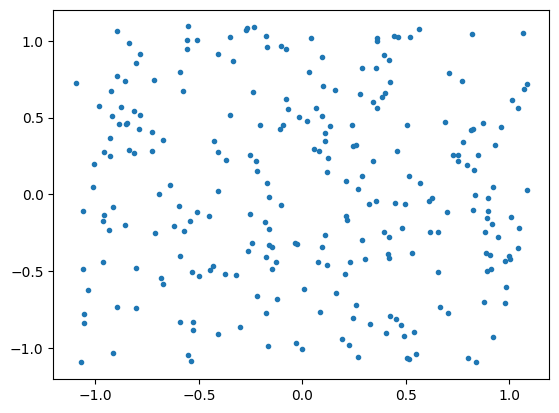

In [46]:
PC_ensembles = es.get_place_cell_ensembles(env_size = 2.2,  neurons_seed = 15, 
                                            targets_type = 'softmax', lstm_init_type='softmax', 
                                            n_pc = [256], pc_scale = [0.01])
HD_ensembles = es.get_head_direction_ensembles(neurons_seed = 10, targets_type = 'softmax', 
                                                lstm_init_type='softmax', 
                                                n_hdc = [12], hdc_concentration = [20])
HC_ensembles = PC_ensembles + HD_ensembles 
# model = lstm.GridTorch(HC_ensembles, (BATCH_SIZE, 100, 3)).cuda()
model = lstm.GridTorch(HC_ensembles, (BATCH_SIZE, 100, 3))

plt.plot(model.target_ensembles[0].means[:,0], model.target_ensembles[0].means[:,1],'.')
plt.show()

### Prepare for data set

In [51]:
data_params = {'batch_size': BATCH_SIZE,
              'shuffle': True,
              'num_workers': 6, # num cpus,
              }

test_params = {'batch_size': 100,
              'shuffle': True,
              'num_workers': 6, # num cpus,
              }

dataset = Dataset(data_loc = './data/torch/', batch_size=data_params['batch_size'])
data_generator = data.DataLoader(dataset, **data_params)
test_generator = data.DataLoader(dataset, **test_params)

### Define optimizing methods

#### (1) optimizer and loss function

In [52]:
params = model.parameters()
logsoftmax = nn.LogSoftmax(dim=-1)
optimiser = torch.optim.RMSprop(params, lr=LR, momentum=MOMENTUM, alpha=0.9, eps=1e-10)

def cross_entropy(pred, soft_targets):
    logsoftmax = nn.LogSoftmax(dim=-1)
    return torch.sum(- soft_targets * logsoftmax(pred), -1)
def get_loss(logits_pc, logits_hd, pc_targets, hd_targets, bottleneck_acts):
    pc_loss = cross_entropy(logits_pc,pc_targets)
    hd_loss = cross_entropy(logits_hd, hd_targets)

    return torch.mean(pc_loss + hd_loss)



### (2) Loading previously trained network (optional)

In [53]:
def get_latest_model_file(folder):
    """
    returns the location of the newest file in the provided foler path
    note: folder path NEEDS to end on a /
    returns None if no files were found in given location
    """
    files = glob.glob(folder + 'model_epoch_*.pt')

    if files == []:
        return None
    newest_file = max(files, key=os.path.getctime)
    return newest_file

### Training loop

In [54]:
for e in range(1, N_EPOCHS*100+1):
    model.train()
    step = 0 
    losses = []
    for X, y in data_generator:
        optimiser.zero_grad()
#        idx = idx +1
        (init_pos, init_hd, inputs, target_pos, target_hd, initial_conds, ensembles_targets) = \
        encode_inputs(X, y, PC_ensembles, HD_ensembles, cuda=False)
        outs = model.forward(inputs, initial_conds)
        bottleneck_acts, logits_pc, logits_hd, pc_targets, hd_targets = \
        decode_outputs(outs, ensembles_targets, cuda=False)
        loss = get_loss(logits_pc, logits_hd, pc_targets, hd_targets, bottleneck_acts)
        loss += model.l2_loss * WEIGHT_DECAY
        loss.backward()
        torch.nn.utils.clip_grad_value_(params, GRAD_CLIPPING)
        optimiser.step()
        losses.append(loss.clone().item())
        
#        if idx > 2:
        if step > STEPS_PER_EPOCH:
            break
        step += 1
    print('EPOCH', e, 'LOSS:', torch.mean(torch.Tensor(losses)))
    
    ## evalulation routine
    if e % 100 == 0 and e > 0:
        state_dict = model.state_dict()
        for k, v in state_dict.items():
            state_dict[k] = v.cpu()
        torch.save(state_dict, './model_epoch_NEW_{}.pt'.format(e))
#        with torch.no_grad():
#            Grid.eval()
#            for data in test_generator:
#                test_X, test_Y = data
#                (init_pos, init_hd, inputs, target_pos, target_hd, initial_conds, ensembles_targets) = encode_inputs(test_X, test_Y, PC_ensembles, HD_ensembles, cuda=True)
#                outs = Grid.forward(inputs, initial_conds)
#                bottleneck_acts, logits_pc, logits_hd, pc_targets, hd_targets = decode_outputs(outs, ensembles_targets, cuda=True)
#                loss = get_loss(logits_pc, logits_hd, pc_targets, hd_targets, bottleneck_acts)
                
#                print('LOSS:', loss)
                
#                break

/Users/sskim/Documents/Research/Study/CCN_Course/Tutorial-GridCell/dataloading.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data = torch.load(ID)
/Users/sskim/D

RuntimeError: Expected !nested_tensorlist[0].empty() to be true, but got false.  (Could this error message be improved?  If so, please report an enhancement request to PyTorch.)

### Plot grid-patterns

In [ ]:
#### Load a trained model
model.load_state_dict(torch.load('./trained_models/model_epoch_new_100000.pt', weights_only=True))
model = model.cpu()

data_params = {'batch_size': 1000,
              'shuffle': True,
              'num_workers': 6, # num cpus,
              }
data_generator = data.DataLoader(dataset, **data_params)

for X, y in data_generator:
    
    break

init_pos , init_hd, ego_vel = X
target_pos, target_hd = y

initial_conds = encode_initial_conditions(init_pos ,
                                                init_hd,
                                                PC_ensembles,
                                                HD_ensembles)
ensembles_targets = encode_targets(target_pos,
                                        target_hd,
                                        PC_ensembles,
                                        HD_ensembles)


model.eval()

outs = model.forward(ego_vel.transpose(1, 0), initial_conds)
logits_hd, logits_pc, bottleneck_acts, lstm_states, _ = outs


acts = bottleneck_acts.transpose(1,0).detach().numpy()
pos_xy = target_pos.detach().numpy()


# Create scorer objects
starts = [0.2] * 10
ends = np.linspace(0.4, 1.0, num=10)
masks_parameters = zip(starts, ends.tolist())
scorer = GridScorer(20, ((-1.1, 1.1), (-1.1, 1.1)),
                                    masks_parameters)

scores = utils.get_scores_and_plot(scorer, pos_xy, acts, '.', 'grid_pattern.pdf')

/Users/sskim/Documents/Research/Study/CCN_Course/Tutorial-GridCell/dataloading.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data = torch.load(ID)
/Users/sskim/D

In [87]:
from IPython.display import IFrame
IFrame("grid_pattern.pdf", width=1400, height=1000)

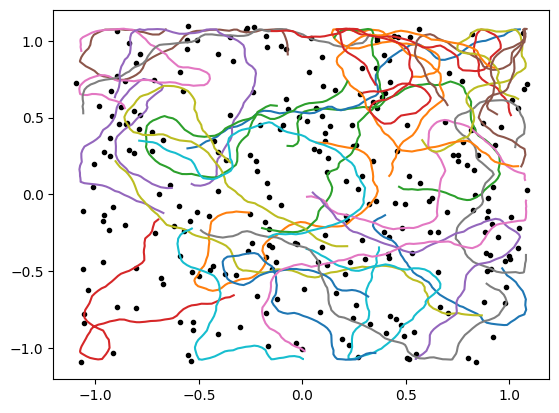

In [18]:
plt.plot(model.target_ensembles[0].means[:,0], model.target_ensembles[0].means[:,1],'k.')
plt.plot(pos_xy[:30,:,0].T,pos_xy[:30,:,1].T)
plt.show()